In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys

import jax
import jax.numpy as jnp

import numpy as np
from scipy import stats
import pickle
import logging
from tqdm import tqdm
import json

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../notebooks/matplotlibrc")

[gpu(id=0)]


In [2]:
sys.path.append("..")
from models.np_model import NPModel
from utils.multi_corner import multi_corner
from utils.validation import find_hdi_prob, roc_finite_sample_band

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Test fit

In [3]:
npmodel = NPModel(
    non_poissonian=True, l_max=0,
    dif_names=["ModelO", "ModelA", "ModelF"],
    bulge_hybrid=True,
    bulge_template_names=["mcdermott2022", "mcdermott2022_bbp", "mcdermott2022_x", "macias2019", "coleman2019"],
    vary_gamma=True,
    vary_disk=True,
    ps_cat="3fgl", r_outer=25, band_mask_range=2.,
    nside=128, n_exp=1, debug_model=False,
)

Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/validating/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [3]:
run_dir = "../outputs/poiss_sim/np_p_230827"

In [6]:
i = 0
counts = jnp.array(np.load(f"{run_dir}/counts_{i}.npy"), dtype=jnp.int32)
svi_results = npmodel.fit_svi(
    jax.random.PRNGKey(4234),
    guide='iaf', num_flows=5, hidden_dims=[256, 256],
    n_steps=20000, lr=5e-5, num_particles=8, data=counts
)
pickle.dump(svi_results, open(f"{run_dir}/svi_results_{i}.p", 'wb'))
samples = npmodel.get_svi_samples(
    rng_key=jax.random.PRNGKey(42),
    num_samples=50000,
)
pickle.dump(samples, open(f"{run_dir}/samples_{i}.p", 'wb'))

100%|██████████| 20000/20000 [36:39<00:00,  9.09it/s, init loss: 26342.6610, avg. loss [19001-20000]: 18399.9629]


In [ ]:
rng_key = jax.random.PRNGKey(42)
mcmc = npmodel.run_nuts(
    num_chains=4, num_warmup=500, num_samples=10000, step_size=0.01,
    rng_key=rng_key, data=counts
)

### 1.1. View

In [4]:
samples = pickle.load(open('../outputs/poiss_sim/np_p_230827/samples_0.p', 'rb'))

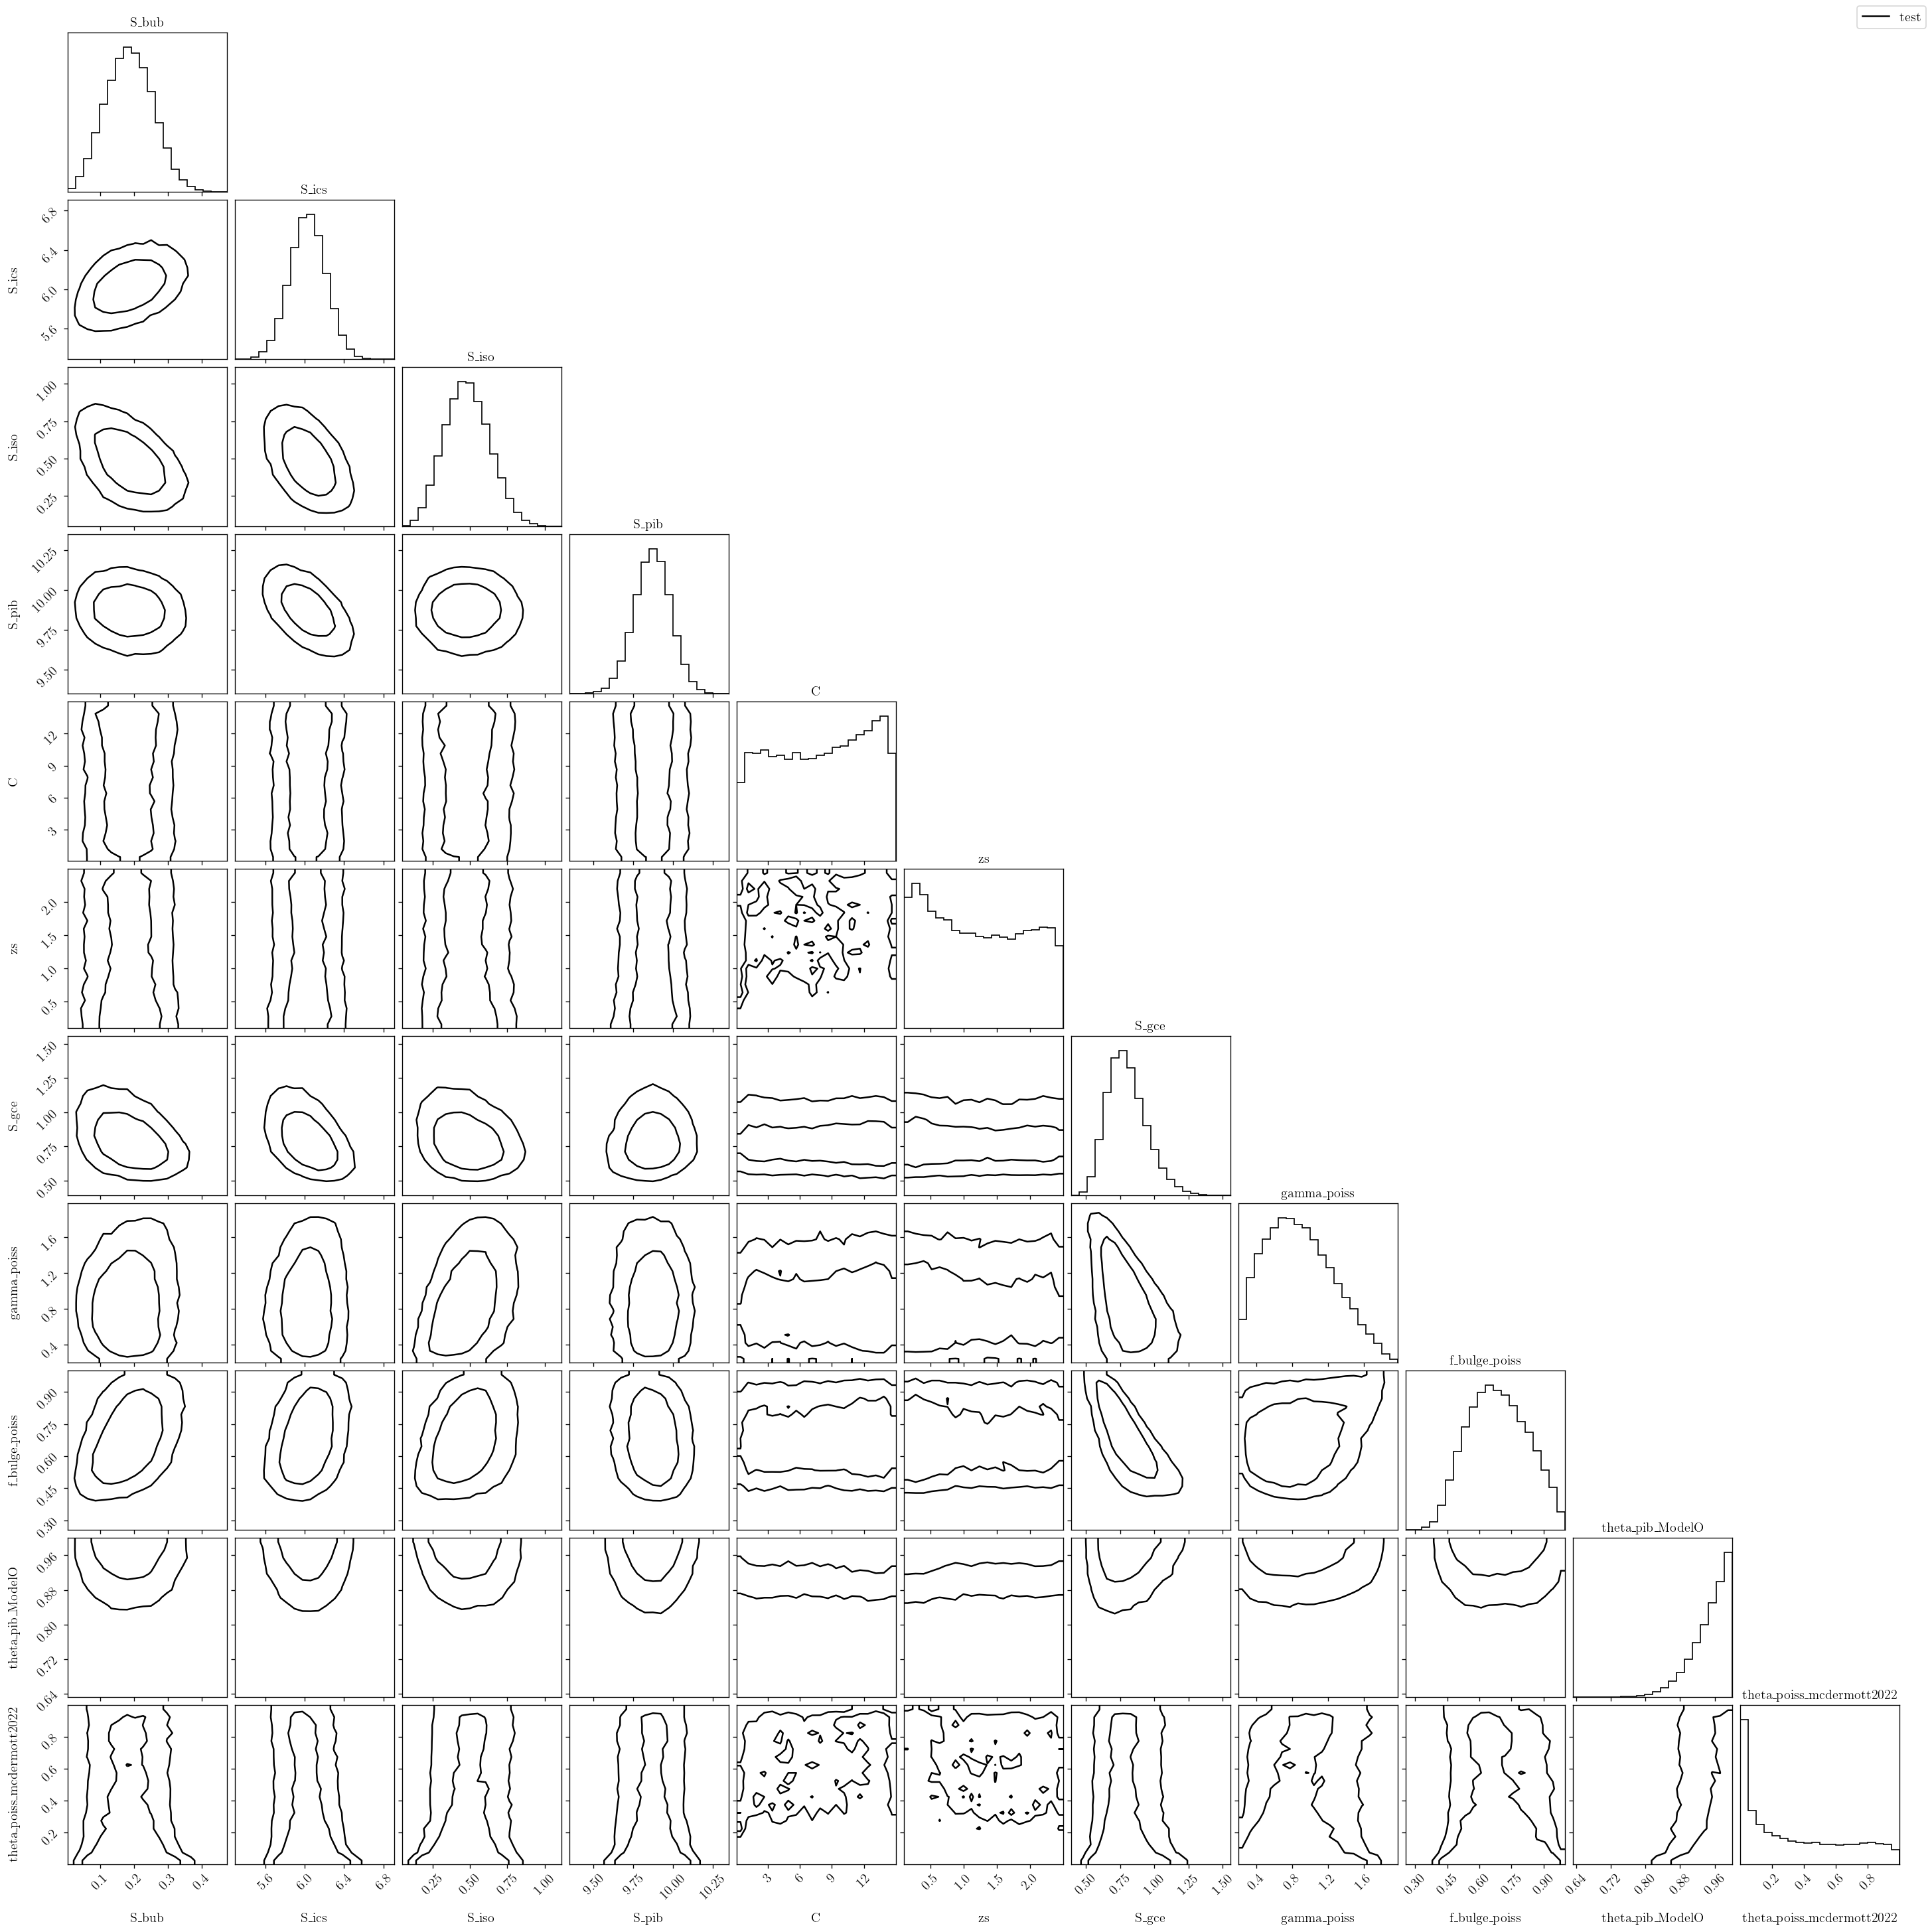

In [9]:
samples_dict = {
    '' : samples
}
colors_dict = {
    '' : 'k'
}
labels_dict = {
    '' : 'test'
}
plot_var_names = [
    'S_bub', 'S_ics', 'S_iso', 'S_pib',
    'C', 'zs',
    'S_gce', 'gamma_poiss', 'f_bulge_poiss',
    'theta_pib_ModelO', 'theta_poiss_mcdermott2022'
]

logging.getLogger().setLevel(logging.ERROR)
multi_corner(
    samples_dict, plot_var_names,
    colors_dict=colors_dict, labels_dict=labels_dict,
    hist_bin_factor=1, save_fn=None
)

## 2. Coverage test

In [23]:
run_dir = "../outputs/poisson_sim/run_230718"
truth_dict = json.load(open(f"{run_dir}/truth.json", 'r'))

### 2.1 Truth and bias

In [24]:
k = 'S_gce'
true_val = truth_dict[k]
print(k, true_val)

S_gce 1.0


In [25]:
fit_val_arr = []
sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]
for fn in tqdm(sample_fns):
    #sk = k if k != 'S_pib' else 'S_dif'
    s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
    fit_val_arr.append(np.array(s['S_gce']))
fit_val_arr = np.array(fit_val_arr)
fit_mean = np.mean(fit_val_arr)
print(fit_mean)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [02:16<00:00,  1.37s/it]

1.0879191836106563


In [26]:
sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]
ps = []
for fn in tqdm(sample_fns):
    #sk = k if k != 'S_pib' else 'S_dif'
    s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
    samples = np.array(s['S_gce'])
    p = find_hdi_prob(samples, fit_mean, level=15)
    ps.append(p)
ps.sort()

100%|██████████| 100/100 [00:02<00:00, 43.01it/s]


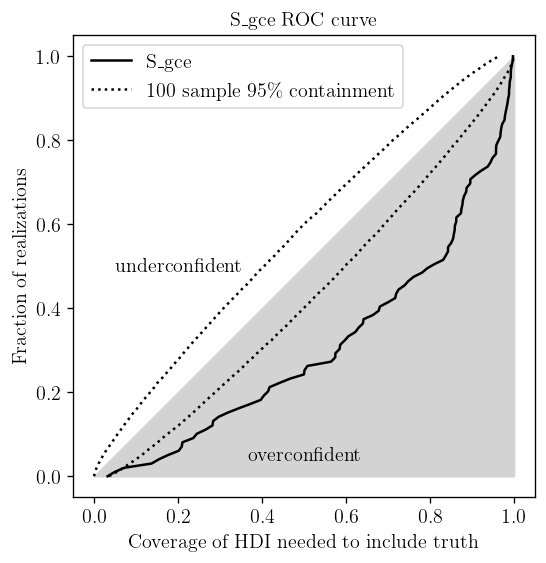

In [31]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.fill_between([0,1], [0,1], color='lightgray')
ax.plot(ps, np.linspace(0, 1, len(ps)), color='k', label='S_gce')

invcdf_lower, invcdf_upper = roc_finite_sample_band(100)
ax.plot(invcdf_upper, np.linspace(0, 1, 100), 'k:', label='100 sample 95\% containment')
ax.plot(invcdf_lower, np.linspace(0, 1, 100), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations',
           title='S_gce ROC curve')
ax.text(0.5, 0.05, 'overconfident', ha='center', va='center')
ax.text(0.05, 0.5, 'underconfident', ha='left', va='center')
ax.legend()

fig.savefig('plots/S_gce_ROC.pdf');

### 2.2 View posteriors

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [02:36<00:00,  1.56s/it]


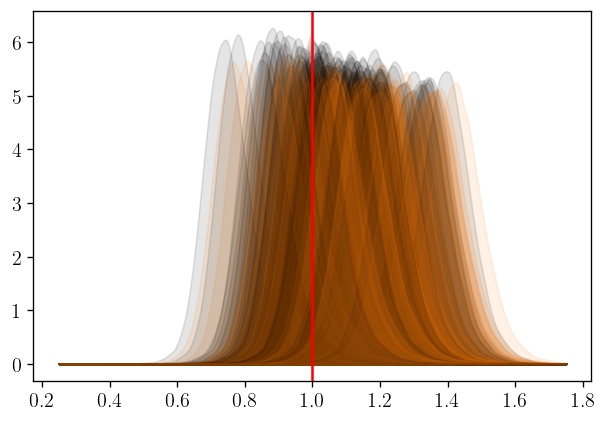

In [18]:
fig, ax = plt.subplots()

sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]

for fn in tqdm(sample_fns):
    #sk = k if k != 'S_pib' else 'S_dif'
    s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
    samples = np.array(s['S_gce'])
    kde = stats.gaussian_kde(samples)
    val_s = np.linspace(0.25, 1.75, 1000)
    ax.fill_between(val_s, kde(val_s), color='k', alpha=0.1)
    samples = np.array(s['S_gce']) + np.array(s['Sps_gce'])
    kde = stats.gaussian_kde(samples)
    val_s = np.linspace(0.25, 1.75, 1000)
    ax.fill_between(val_s, kde(val_s), color='C1', alpha=0.1)
ax.axvline(true_val, color='red')

In [18]:
sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]
std_s = []
for fn in tqdm(sample_fns):
    sk = k if k != 'S_pib' else 'S_dif'
    s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
    samples = np.array(s[sk])
    std_s.append(np.std(samples))
print(np.mean(std_s))

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 61.43it/s]

0.07844684


## 3. ROC finite sample band

In [ ]:
from scipy import special

In [21]:
invcdf_arr = []
for _ in tqdm(range(10000)):
    x_sample = np.random.normal(size=100)
    p_sample = (special.erf(np.abs(x_sample)/np.sqrt(2)) - special.erf(-np.abs(x_sample)/np.sqrt(2))) / 2
    invcdf_arr.append(np.sort(p_sample))
invcdf_arr = np.array(invcdf_arr)
invcdf_upper = np.quantile(invcdf_arr, 0.975, axis=0)
invcdf_lower = np.quantile(invcdf_arr, 0.025, axis=0)

100%|██████████| 10000/10000 [00:00<00:00, 48386.47it/s]


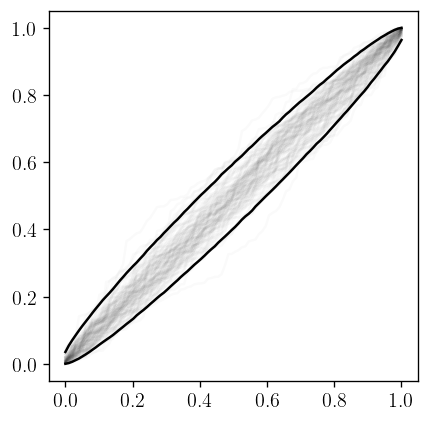

In [22]:
fig, ax = plt.subplots()
for i in range(100):
    ax.plot(np.linspace(0, 1, 100), invcdf_arr[i], 'k-', alpha=0.02)
ax.plot(np.linspace(0, 1, 100), invcdf_upper, 'k')
ax.plot(np.linspace(0, 1, 100), invcdf_lower, 'k')
ax.set_aspect('equal')